### The data set has information about features of silhouette extracted from the images of different cars

Four "Corgie" model vehicles were used for the experiment: a double decker bus, Cheverolet van, Saab 9000 and an Opel Manta 400 cars. This particular combination of vehicles was chosen with the expectation that the bus, van and either one of the cars would be readily distinguishable, but it would be more difficult to distinguish between the cars.



In [211]:
import pandas as pd
import numpy as np
import math

# importing ploting libraries
import matplotlib.pyplot as plt   
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

### 1. Read the dataset using function .dropna() - to avoid dealing with NAs as of now

In [212]:
# import data set
df = pd.read_csv( 'vehicle.csv' )
df.head(5)
# shape
df.shape

(846, 19)

In [213]:
# check dataset
df.info()
# study the Data Distribution for each attribute
df.describe().T
# check how many missing values
df.isnull().sum()
# Drop Missing Values
df.dropna(inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
compactness                    846 non-null int64
circularity                    841 non-null float64
distance_circularity           842 non-null float64
radius_ratio                   840 non-null float64
pr.axis_aspect_ratio           844 non-null float64
max.length_aspect_ratio        846 non-null int64
scatter_ratio                  845 non-null float64
elongatedness                  845 non-null float64
pr.axis_rectangularity         843 non-null float64
max.length_rectangularity      846 non-null int64
scaled_variance                843 non-null float64
scaled_variance.1              844 non-null float64
scaled_radius_of_gyration      844 non-null float64
scaled_radius_of_gyration.1    842 non-null float64
skewness_about                 840 non-null float64
skewness_about.1               845 non-null float64
skewness_about.2               845 non-null float64
hollows_ratio    

### 2. Print/ Plot the dependent (categorical variable) - Class column

Since the variable is categorical, you can use value_counts function

In [214]:
df["class"].value_counts()

car    413
bus    205
van    195
Name: class, dtype: int64

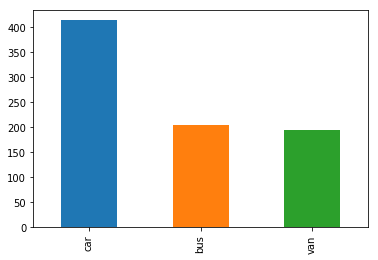

In [215]:
df["class"].value_counts().plot(kind='bar')


### Check for any missing values in the data 

In [216]:
# check how many missing values
df.isnull().sum()

compactness                    0
circularity                    0
distance_circularity           0
radius_ratio                   0
pr.axis_aspect_ratio           0
max.length_aspect_ratio        0
scatter_ratio                  0
elongatedness                  0
pr.axis_rectangularity         0
max.length_rectangularity      0
scaled_variance                0
scaled_variance.1              0
scaled_radius_of_gyration      0
scaled_radius_of_gyration.1    0
skewness_about                 0
skewness_about.1               0
skewness_about.2               0
hollows_ratio                  0
class                          0
dtype: int64

### 3. Standardize the data 

In [217]:
from scipy.stats import zscore

X_attributes = df.drop("class", axis=1)

X_attributes = X_attributes.apply(zscore) 

Since the dimensions of the data are not really known to us, it would be wise to standardize the data using z scores before we go for any clustering methods.
You can use zscore function to do this

### K - Means Clustering

### 4. Assign a dummy array called distortion

In [218]:
distortion = []

You can later use this array to plot the elbow plot

### 5. Calculating distortion - C distance

In [219]:
from sklearn.cluster import KMeans

Iterating values of k from 1 to 10 fit K means model
Using c distance - Get the measure for Sum of squares error.

In [220]:
#Finding optimal no. of clusters
from scipy.spatial.distance import cdist
clusters=range(1,10)
distortion=[]

for k in clusters:
    model=KMeans(n_clusters=k)
    model.fit(X_attributes)
    prediction=model.predict(X_attributes)
    distortion.append(sum(np.min(cdist(X_attributes, model.cluster_centers_, 'euclidean'), axis=1)) / X_attributes.shape[0])




In [221]:
# combine the cluster_range and cluster_errors into a dataframe by combining them
clusters_df = pd.DataFrame( { "num_clusters":clusters, "cluster_errors": distortion} )
clusters_df[0:10]

,num_clusters,cluster_errors
0,1,3.939299
1,2,2.966824
2,3,2.642794
3,4,2.549831
4,5,2.428722
5,6,2.315317
6,7,2.242938
7,8,2.174561
8,9,2.116691


### 6. Plotting Elbow/ Scree Plot

Text(0.5, 1.0, 'Selecting k with the Elbow Method')

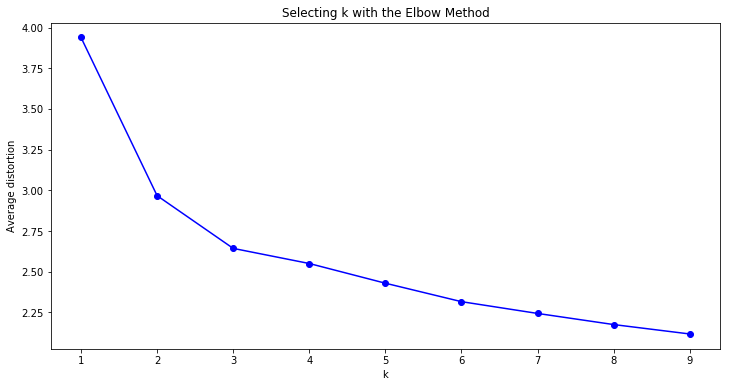

In [222]:
# Elbow plot

plt.figure(figsize=(12,6))
plt.plot(clusters, distortion, 'bx-',marker = "o" )
plt.xlabel('k')
plt.ylabel('Average distortion')
plt.title('Selecting k with the Elbow Method')

Use Matplotlib to plot the scree plot - Note: Scree plot plots distortion vs the no of clusters

### Find out the optimal value of K

In [223]:
# Based on the above Elbow Plot , the Optimal K is 3

In [224]:
optimal_K = 3

### Using optimal value of K - Cluster the data. 
Note: Since the data has more than 2 dimension we cannot visualize the data. As an alternative, we can observe the centroids and note how they are distributed across different dimensions

In [225]:

final_model=KMeans(optimal_K)
final_model.fit(X_attributes)
prediction=final_model.predict(X_attributes)


You can use kmeans.cluster_centers_ function to pull the centroid information from the instance

In [226]:
centroids = final_model.cluster_centers_
print (centroids)

[[-0.2339617  -0.57387481 -0.30776905 -0.03041322  0.2050726  -0.11653151
  -0.45904181  0.32506329 -0.48798836 -0.53604446 -0.41380935 -0.46366305
  -0.60155031 -0.61924057 -0.06177969  0.01066762  0.81278556  0.69897299]
 [ 1.13076532  1.17094237  1.19500584  1.01909505  0.21505188  0.34250798
   1.27180461 -1.19061224  1.27548416  1.09266768  1.22038121  1.28132727
   1.07954232 -0.02879497  0.16229031  0.26566456 -0.00535553  0.18380067]
 [-0.91987072 -0.52009251 -0.89320752 -1.06435572 -0.50042171 -0.2190738
  -0.7791213   0.86589322 -0.74535635 -0.484632   -0.78240328 -0.78341064
  -0.38498232  0.83878747 -0.09524349 -0.30171562 -1.05420601 -1.11069466]]


### 7. Store the centroids in a dataframe with column names from the original dataset given 

Hint: Use pd.Dataframe function 

In [227]:
df.columns

Index(['compactness', 'circularity', 'distance_circularity', 'radius_ratio',
       'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scatter_ratio',
       'elongatedness', 'pr.axis_rectangularity', 'max.length_rectangularity',
       'scaled_variance', 'scaled_variance.1', 'scaled_radius_of_gyration',
       'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1',
       'skewness_about.2', 'hollows_ratio', 'class'],
      dtype='object')

In [228]:
centroid_df = pd.DataFrame(centroids, columns=list(X_attributes.columns)) 
centroid_df.head(10)

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
0,-0.233962,-0.573875,-0.307769,-0.030413,0.205073,-0.116532,-0.459042,0.325063,-0.487988,-0.536044,-0.413809,-0.463663,-0.601550,-0.619241,-0.061780,0.010668,0.812786,0.698973
1,1.130765,1.170942,1.195006,1.019095,0.215052,0.342508,1.271805,-1.190612,1.275484,1.092668,1.220381,1.281327,1.079542,-0.028795,0.162290,0.265665,-0.005356,0.183801
2,-0.919871,-0.520093,-0.893208,-1.064356,-0.500422,-0.219074,-0.779121,0.865893,-0.745356,-0.484632,-0.782403,-0.783411,-0.384982,0.838787,-0.095243,-0.301716,-1.054206,-1.110695


In [229]:
#Append the prediction 
df["GROUP"] = prediction
print("Groups Assigned : \n")
df[["class", "GROUP"]]

Groups Assigned : 



,class,GROUP
0,van,0
1,van,0
2,car,1
3,van,0
4,bus,2
6,bus,0
7,van,0
8,van,0
10,van,0
11,car,0


### Use kmeans.labels_ function to print out the labels of the classes

In [230]:
kmeans.labels_

array([2, 2, 1, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 2, 1, 0, 0, 2, 2, 1,
       2, 0, 1, 1, 0, 2, 2, 2, 1, 2, 0, 1, 1, 0, 1, 0, 0, 2, 1, 0, 0, 0,
       0, 2, 0, 2, 1, 2, 1, 2, 2, 0, 1, 0, 1, 0, 0, 0, 2, 0, 1, 2, 1, 1,
       2, 0, 2, 1, 2, 0, 0, 1, 2, 0, 2, 1, 2, 0, 2, 0, 1, 2, 1, 2, 0, 1,
       0, 0, 1, 0, 0, 2, 2, 0, 1, 1, 0, 0, 1, 2, 2, 0, 0, 0, 2, 1, 1, 2,
       0, 0, 2, 0, 0, 0, 0, 0, 2, 1, 1, 2, 2, 0, 1, 1, 0, 2, 0, 2, 2, 1,
       0, 2, 1, 2, 2, 2, 2, 1, 2, 2, 1, 2, 1, 2, 0, 2, 0, 1, 2, 2, 1, 1,
       2, 1, 0, 0, 1, 1, 2, 1, 2, 2, 2, 2, 0, 1, 0, 2, 0, 1, 2, 2, 2, 1,
       2, 1, 2, 1, 2, 0, 1, 0, 0, 0, 2, 2, 1, 1, 2, 2, 2, 0, 1, 2, 2, 2,
       1, 0, 0, 1, 0, 2, 1, 0, 0, 0, 2, 1, 2, 1, 0, 0, 0, 0, 1, 2, 0, 2,
       1, 0, 2, 2, 0, 1, 0, 0, 2, 2, 1, 0, 1, 0, 2, 2, 1, 2, 2, 1, 1, 0,
       2, 2, 2, 1, 0, 2, 2, 0, 0, 2, 2, 1, 2, 0, 0, 1, 2, 2, 0, 0, 1, 0,
       2, 1, 0, 2, 1, 2, 2, 1, 2, 1, 0, 2, 2, 1, 2, 2, 2, 0, 2, 1, 1, 1,
       1, 0, 2, 1, 0, 0, 0, 2, 0, 1, 1, 0, 1, 2, 0,

## Hierarchical Clustering 

### 8. Variable creation

For Hierarchical clustering, we will create datasets using multivariate normal distribution to visually observe how the clusters are formed at the end

In [231]:
a = np.random.multivariate_normal([10, 0], [[3, 1], [1, 4]], size=[100,])
b = np.random.multivariate_normal([0, 20], [[3, 1], [1, 4]], size=[50,])
c = np.random.multivariate_normal([10, 20], [[3, 1], [1, 4]], size=[100,])

### 9. Combine all three arrays a,b,c into a dataframe

In [232]:
array = np.concatenate((a, b, c), axis=0)
data = pd.DataFrame(array, columns=['col1' , 'col2']) 
print (data)

          col1       col2
0     7.759358  -0.669797
1    10.669993   0.160984
2    12.401028   1.096381
3    10.623687   1.989571
4     5.670554  -4.266380
5     7.389138  -1.263797
6    10.281790  -3.139381
7     9.124454  -1.654510
8     9.921662  -3.576998
9     9.315134   0.362119
10    8.814938  -2.369639
11   12.467808  -2.572572
12    9.759956  -1.031564
13   10.688612  -2.608346
14    8.903306  -3.053808
15    9.027927  -1.244473
16    9.998572  -0.675008
17   11.288310  -4.798537
18    7.953858  -1.799674
19   10.624826   1.337941
20   10.869178  -0.314252
21   11.702193  -2.995788
22    9.256773  -2.022211
23   11.274222   0.142623
24    8.500727  -1.237192
25    8.932297  -2.410157
26    8.373647  -1.249535
27    8.630213   4.178362
28    8.419832  -3.422657
29    8.113877  -0.890603
..         ...        ...
220  13.596963  23.739339
221   8.153579  19.324283
222  12.001037  18.705755
223   8.579621  19.474636
224   9.954507  19.431241
225   8.997268  18.462138
226  10.7255

### 10. Use scatter matrix to print all the 3 distributions

C:\Users\Suchi\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


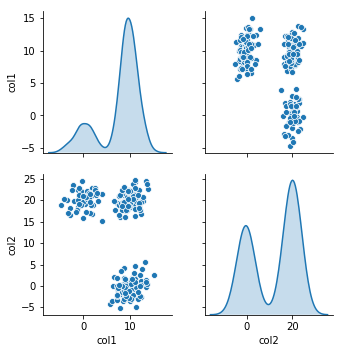

In [233]:
#importing seaborn for statistical plots
import seaborn as sns
sns.pairplot(data, diag_kind='kde')

### 11. Find out the linkage matrix

In [234]:
from sklearn.cluster import AgglomerativeClustering 

Use ward as linkage metric and distance as Eucledian

In [235]:
model = AgglomerativeClustering(n_clusters=6, affinity='euclidean',  linkage='ward')

In [236]:
model.fit(data)

AgglomerativeClustering(affinity='euclidean', compute_full_tree='auto',
            connectivity=None, linkage='ward', memory=None, n_clusters=6,
            pooling_func='deprecated')

### 12. Plot the dendrogram for the consolidated dataframe

In [237]:
from scipy.cluster.hierarchy import cophenet, dendrogram, linkage

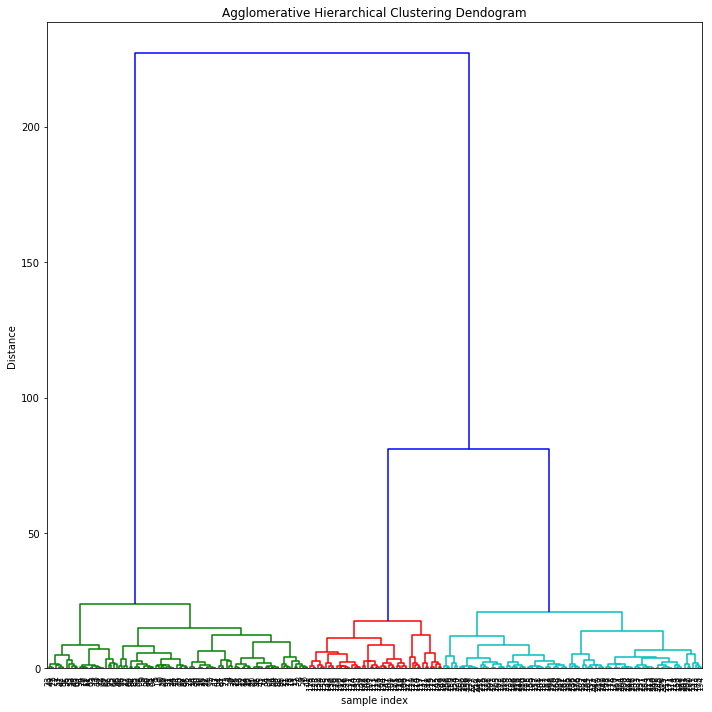

In [238]:
Z = linkage(data, 'ward') 

plt.figure(figsize=(10, 10))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(Z, leaf_rotation=90.,color_threshold = 40, leaf_font_size=8. )
plt.tight_layout()

### 13. Recreate the dendrogram for last 12 merged clusters 

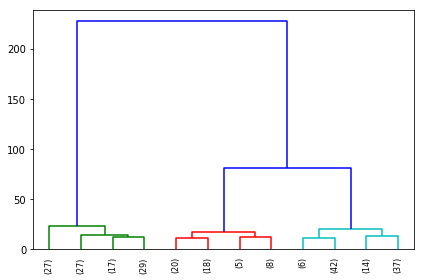

In [239]:

dendrogram(Z, leaf_rotation=90.,color_threshold = 40, leaf_font_size=8., truncate_mode='lastp',p=12 )
plt.tight_layout()

Hint: Use truncate_mode='lastp' attribute in dendrogram function to arrive at dendrogram 

### 14. From the truncated dendrogram, find out the optimal distance between clusters which u want to use an input for clustering data

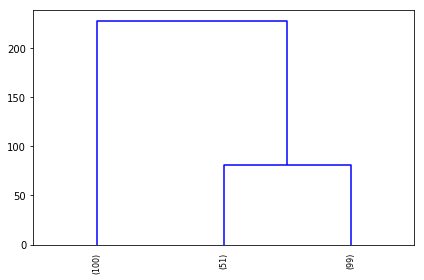

In [240]:
# find Optimal distance with p = 3
dendrogram(Z, leaf_rotation=90.,color_threshold = 40, leaf_font_size=8., truncate_mode='lastp',p=3 )
plt.tight_layout()

In [241]:
max_d = 50

### 15. Using this distance measure and fcluster function to cluster the data into 3 different groups

In [242]:
import scipy
import scipy.cluster.hierarchy as sch

sch.fcluster(Z, max_d, criterion='distance')

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3], dtype=int32)

### Use matplotlib to visually observe the clusters in 2D space 

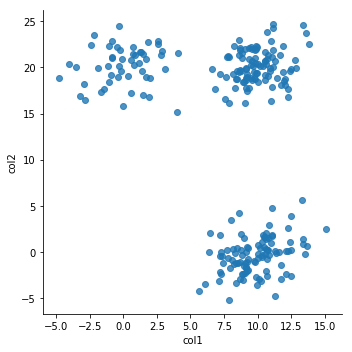

In [243]:
sns.lmplot( "col1", "col2", data=data, fit_reg=False )